EDA FOR AMIR Benston

# This notebook will set out to investigate patterns in perpetrator and victim race combinations, specifically whether victims tend to share the same race as the perpetrator and how evenly distributed vicim races are across different perpetrator groups

In [200]:
import pandas as pd

# allows us to use the pandas package in python which we will use for data analysis and manipulation

import matplotlib.pyplot as plt 

# allows us to use the matplotlibs pyplot submodule in order to get a matlab like interface; which we will use for data visualization

In [201]:
shootings = pd.read_csv('../data/processed/clean_data.csv')

# loads the data from clean_data.csv into a pandas dataframe under the variable name shootings

In [202]:
shootings.head()

# displays the first 5 rows of the shootings dataframe


,Unnamed: 0,incident_key,occur_date,occur_time,boro,precinct,jurisdiction_code,statistical_murder_flag,perp_age_group,perp_sex,...,:created_at,:updated_at,:@computed_region_yeji_bk3q,:@computed_region_92fq_4b7q,:@computed_region_sbqj_enih,:@computed_region_efsh_h5xi,:@computed_region_f5dn_yrer,location_desc,loc_of_occur_desc,loc_classfctn_desc
0,0,209281500,2020-02-08T00:00:00.000,12:13:00,QUEENS,115,0.0,True,25-44,M,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,3.0,21.0,73.0,14510.0,65.0,NaN,NaN,NaN
1,1,209281497,2020-02-08T00:00:00.000,02:20:00,BROOKLYN,76,0.0,True,25-44,M,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,2.0,7.0,48.0,13514.0,14.0,NaN,NaN,NaN
2,2,209281498,2020-02-07T00:00:00.000,22:50:00,BROOKLYN,75,0.0,False,25-44,M,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,2.0,37.0,47.0,17214.0,45.0,NaN,NaN,NaN
3,3,209099251,2020-02-05T00:00:00.000,04:02:00,QUEENS,101,0.0,False,NaN,NaN,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,3.0,47.0,59.0,20529.0,51.0,MULTI DWELL - APT BUILD,NaN,NaN
4,4,209098666,2020-02-05T00:00:00.000,23:13:00,MANHATTAN,34,0.0,False,18-24,M,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,4.0,39.0,22.0,13098.0,47.0,MULTI DWELL - APT BUILD,NaN,NaN


In [203]:
shootings.tail()

# displays the last 5 rows of the dataframe

,Unnamed: 0,incident_key,occur_date,occur_time,boro,precinct,jurisdiction_code,statistical_murder_flag,perp_age_group,perp_sex,...,:created_at,:updated_at,:@computed_region_yeji_bk3q,:@computed_region_92fq_4b7q,:@computed_region_sbqj_enih,:@computed_region_efsh_h5xi,:@computed_region_f5dn_yrer,location_desc,loc_of_occur_desc,loc_classfctn_desc
28995,995,240338259,2022-02-09T00:00:00.000,00:45:00,BROOKLYN,75,0.0,True,(null),(null),...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,2.0,37.0,47.0,17215.0,45.0,PVT HOUSE,OUTSIDE,STREET
28996,996,240379307,2022-02-09T00:00:00.000,13:33:00,BROOKLYN,90,2.0,False,(null),(null),...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,2.0,30.0,56.0,17213.0,36.0,MULTI DWELL - PUBLIC HOUS,INSIDE,HOUSING
28997,997,240321242,2022-02-08T00:00:00.000,00:30:00,BRONX,48,0.0,False,(null),(null),...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,5.0,43.0,31.0,11269.0,35.0,(null),OUTSIDE,STREET
28998,998,240321668,2022-02-08T00:00:00.000,20:02:00,BROOKLYN,69,0.0,False,25-44,M,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,2.0,8.0,42.0,13827.0,5.0,(null),OUTSIDE,STREET
28999,999,240321668,2022-02-08T00:00:00.000,20:02:00,BROOKLYN,69,0.0,False,18-24,M,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,2.0,8.0,42.0,13827.0,5.0,(null),OUTSIDE,STREET


In [204]:
shootings.info()

# prints a full summary of dataframe including total number of rows and columns, non-null count, data type and name for each column etc 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29000 entries, 0 to 28999
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Unnamed: 0                   29000 non-null  int64  
 1   incident_key                 29000 non-null  int64  
 2   occur_date                   29000 non-null  object 
 3   occur_time                   29000 non-null  object 
 4   boro                         29000 non-null  object 
 5   precinct                     29000 non-null  int64  
 6   jurisdiction_code            28998 non-null  float64
 7   statistical_murder_flag      29000 non-null  bool   
 8   perp_age_group               19703 non-null  object 
 9   perp_sex                     19704 non-null  object 
 10  perp_race                    19704 non-null  object 
 11  vic_age_group                29000 non-null  object 
 12  vic_sex                      29000 non-null  object 
 13  vic_race        

In [205]:
shootings.describe()

# give us descriptive statistics for each numeric column in the dataframe

,Unnamed: 0,incident_key,precinct,jurisdiction_code,latitude,longitude,:@computed_region_yeji_bk3q,:@computed_region_92fq_4b7q,:@computed_region_sbqj_enih,:@computed_region_efsh_h5xi,:@computed_region_f5dn_yrer
count,29000.000000,2.900000e+04,29000.000000,28998.000000,28903.000000,28903.000000,28903.000000,28903.000000,28903.000000,28862.000000,28903.000000
mean,499.500000,1.369615e+08,65.207207,0.318263,40.739519,-73.908989,3.280525,29.829845,40.424489,14713.522625,38.665433
std,288.679968,8.149749e+07,27.373641,0.729037,0.087726,0.065619,1.320795,13.940465,16.924575,3784.021785,20.280171
min,0.000000,1.681403e+07,1.000000,0.000000,40.511586,-74.249303,1.000000,1.000000,1.000000,10090.000000,1.000000
25%,249.750000,7.175669e+07,44.000000,0.000000,40.669045,-73.942736,2.000000,17.000000,27.000000,11605.000000,18.000000
50%,499.500000,1.373719e+08,67.000000,0.000000,40.703146,-73.914762,3.000000,31.000000,40.000000,13512.000000,42.000000
75%,749.250000,2.153030e+08,81.000000,0.000000,40.825389,-73.882660,5.000000,42.000000,52.000000,17215.000000,55.000000
max,999.000000,2.994625e+08,123.000000,2.000000,40.910818,-73.702046,5.000000,51.000000,77.000000,24894.000000,71.000000


In [206]:
shootings['perp_race'].value_counts(dropna=False)


# give us the value counts for each unique value in the perp_race column dropna=False overrides not including null (missing) values



perp_race
BLACK                             11878
NaN                                9296
WHITE HISPANIC                     2583
UNKNOWN                            1665
(null)                             1628
BLACK HISPANIC                     1474
WHITE                               294
ASIAN / PACIFIC ISLANDER            180
AMERICAN INDIAN/ALASKAN NATIVE        2
Name: count, dtype: int64

In [207]:
shootings['vic_race'].value_counts(dropna=False)

# give us the value counts for each unique value in the vic_race column dropna=False overrides not including null (missing) values

vic_race
BLACK                             20486
WHITE HISPANIC                     4334
BLACK HISPANIC                     2914
WHITE                               718
ASIAN / PACIFIC ISLANDER            464
UNKNOWN                              71
AMERICAN INDIAN/ALASKAN NATIVE       13
Name: count, dtype: int64

In [208]:
shootings['perp_race'] = shootings['perp_race'].replace('(null)', pd.NA)

# replaces null strings with true pandas null values NaN

shootings['perp_race'] = shootings['perp_race'].fillna('UNKNOWN')

# coverts our null values to UNKNOWN and combines them with the values already listed as unknown in the dataframe

In [209]:
# perp_race and vic_race combination table 



race_count = shootings.groupby(['perp_race', 'vic_race']).size().reset_index(name='count')

# groupby groups the different combinations of (perp_race and vic_race together) into distinct groups 
# .size tells us the total count for each group of (perp_race and vic_race) combination and put this into a series
#.reset_index(name='count') turns this grouped series back into a regular df with 3 columns perp_race, vic_race and count

race_count['pct_perp_race'] = (race_count['count'] / race_count.groupby('perp_race')['count'].transform('sum') * 100).round(2)

# creates a new column pct_perp_race which will sit next to count and show the percent of shootings committed by that race category each row represents
# race_count['count'] our numerator gives the total shootings for that specfic rows (perp_race, vic_race) combination
# race_count.groupby('perp_race')['count'].transform('sum') our denominator gives us the total count of shootings committed by that rows unique prep_race category transform keeps the shape of the original df
# *100 multiplies each rows fraction by 100 to represent pct_perp_race as a percent
# .round(2) rounds to two decimal places 

race_count = race_count.sort_values(['perp_race', 'count'], ascending=[True, False])

# .sort_values sorts the rows of race_count using the two selected columns perp_race will be in ascending alphabetical order and the highest counts will show first in descending order

display(race_count)




,perp_race,vic_race,count,pct_perp_race
0,AMERICAN INDIAN/ALASKAN NATIVE,BLACK,2,100.00
1,ASIAN / PACIFIC ISLANDER,ASIAN / PACIFIC ISLANDER,66,36.67
2,ASIAN / PACIFIC ISLANDER,BLACK,61,33.89
5,ASIAN / PACIFIC ISLANDER,WHITE HISPANIC,28,15.56
3,ASIAN / PACIFIC ISLANDER,BLACK HISPANIC,14,7.78
4,ASIAN / PACIFIC ISLANDER,WHITE,11,6.11
8,BLACK,BLACK,9374,78.92
12,BLACK,WHITE HISPANIC,1247,10.50
9,BLACK,BLACK HISPANIC,852,7.17
11,BLACK,WHITE,206,1.73


# The following observations examine patterns in shooter and victim race combinations, specifically whether victims tend to share the race as the perpetrator and how evenly distributed victim races are across perpetrator groups

# For instance in shootings on record where the perpetrator was Asian the race of the victim was more evenly distributed then most other race groups. 37% of victims were also Asian which is the most for Asian perpetrators but represents the lowest percent total of the highest amount of victims for a particular perpetrator group. 34% of victims were Black which is the highest percent total of the second most common victim group for any particular perpetrator group. The combination of these two factors makes Asian prep_race data stand out as more evenly distributed.


# In contrast in shootings where the perpetrator was Black the race of the victim was less evenly distributed than other race groups. 79% percent of the victims were also Black which is the highest percent total of any perp_race vic_race combination. The 2nd highest victim group for this category was White Hispanic with 11% which is the lowest percent total for any 2nd place perp_race vic_race combination in our dataset. The combination of these facts about our data leads me to believe in shootings where the perpetrator was Black the race of the victim was less evenly distributed than other race groups as it relates to our dataset.

# I was also able to ascertain that Black was the only victim group that represented at least 15% of shooting victims for all perp_race categories.

# Last but not least for all perp_race categories besides Asian / Pacific Islander, White Hispanic was the second most evenly distributed in regards to the race of victims. White Hispanic was the most represented victim group in this category 42%; the second lowest most represented victim group for all perpetrator race groups. Next was Black victims 34% and 3rd was Black Hispanic 18%. White Hispanic is the only perpetrator group where at least 3 different victim groups represent 18% of victims indicating more even distribution amongst victims.

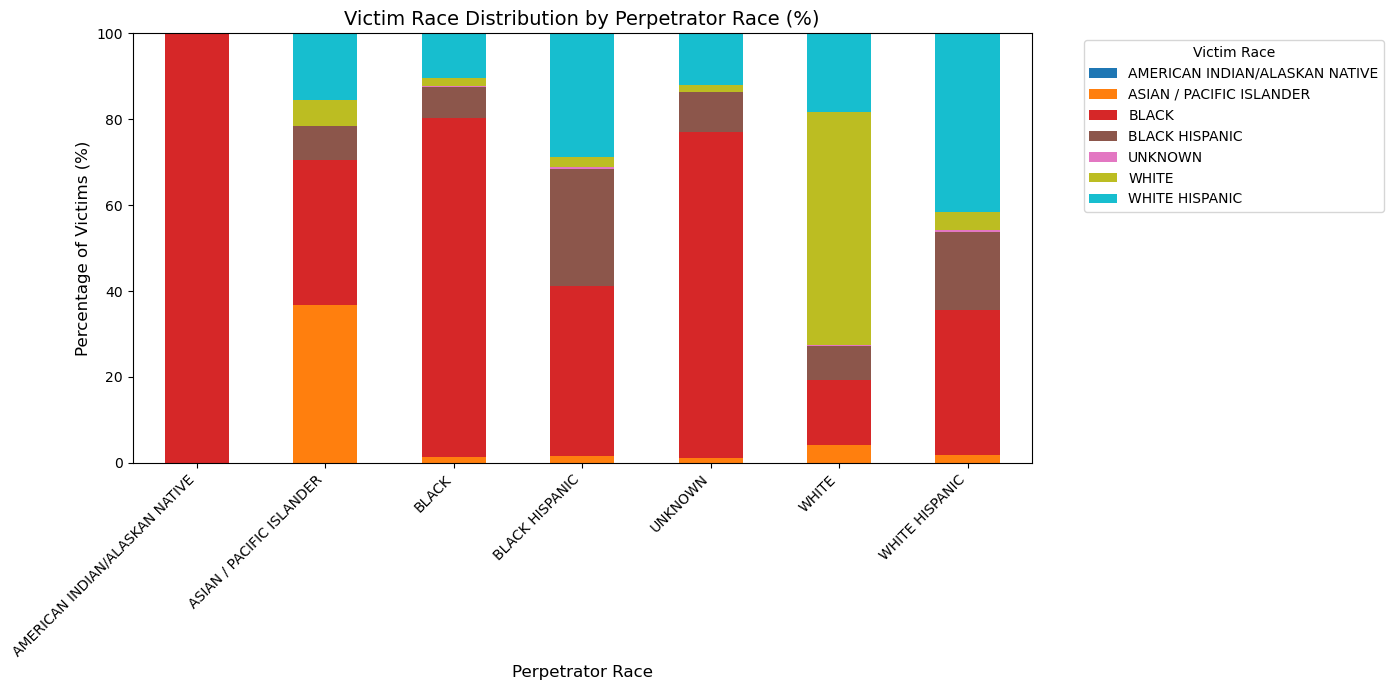

In [ ]:
# Below I will express the following observations as a 100% stacked bar chart showing victim race distribution by perpetrator race
# pivot: perp_race as rows, vic_race as columns, values = pct_perp_race

pivot = race_count.pivot(index='perp_race', columns= 'vic_race', values= 'pct_perp_race').fillna(0)

# .pivot reshapes race_count from long format into wide format
# each unique perp_race becomes a row, each unique vic_race becomes a column
# .fillna(0) fills any missing combinations with 0 since those pairings had no shootings

# 100% stacked bar chart showing victim race distribution by perpetrator race

ax = pivot.plot(kind='bar', stacked=True, figsize=(14,7), colormap='tab10')

# kind='bar' produces a vertical bar chart
# stacked=True stacks each vic_race segment on top of one another per perp_race group
# figsize sets the width and height of the chart in inches
# colormap='tab10' assigns a distinct color to each vic_race category

ax.set_title('Victim Race Distribution by Perpetrator Race (%)', fontsize=14)
ax.set_xlabel('Perpetrator Race', fontsize=12)
ax.set_ylabel('Percentage of Victims (%)', fontsize=12)
ax.set_ylim(0,100)
# set_ylim locks the y axis from 0 to 100 since we are plotting percentages
ax.legend(title='Victim Race', bbox_to_anchor=(1.05,1), loc='upper left')
# moves the legend outside the chart so it doesn't block the bars
plt.xticks(rotation=45, ha='right')
# rotation=45 tilts each label 45 degrees diagonally so long labels won't overlap with each and become unreadable
# ha='right' tells matplot to anchor the right edge of each label to it's tick in the x-axis so I can tell which label goes with what bar
plt.tight_layout()
# makes sure nothing inside the gets overlapped
plt.show()

# From the data visualization we can see that American Indian and Black are the two least distrubuted perpretrators groups though it should be noted American Indian only counts for two total perpetrators. 

# We can also see that Asian, White Hispanic and White are the perpetrator groups with the most distrubution amoungst thier victims.